In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    compute_rate_trend_categories,
    compute_rate_trend_pmf,
    create_flusight_submission,
    RATE_TREND_CATEGORIES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons,
    get_flusight_categorical_horizons,
)
from epymodelingsuite.utils.location import convert_location_name_format


## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202621"#]
REFERENCE_DATE = "2026-05-30"
#WINDOW = "202550-202620"

Choose augmentation and baseline:

In [3]:
#AUGMENTED = True
BASELINE = True
BASELINE_k = 5

These configs are unlikely to need changing:

In [4]:
INCLUDE_SINGLE_STRAIN = True
#DIST_FUNC = "wrmse"
#STRAINS = "h1-h3-b"
#TARGET = "hosp_aug" if AUGMENTED else "hosp"
TARGET_LONG = "flu_hosp_25"
#SUFFIX = "_augmented" if AUGMENTED else ""
LOCAL_PARENT_DIR = "../experiments/multistrain/retro20260615"

Derived config values:

In [5]:
VALUE_COL = "target_baseline_k5" if BASELINE else "target_sum"
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-06-27 00:00:00')

## Data

In [6]:
if INCLUDE_SINGLE_STRAIN:
    # Load single-strain submission file
    single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/retro20260615/{SUBMISSION_WEEK}_single"
    single_fname = f"output_hub_formatted.csv.gz"
    df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
    df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/retro20260615/202621_single/20260617-044209-547ac8e0/outputs/20260617-084647/output_hub_formatted.csv.gz to file:///tmp/tmpzf0zl0xe/output_hub_formatted.csv.gz
  
..


Downloaded: output_hub_formatted.csv.gz


In [7]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_prelim_augmented.csv")
fit_surv_data['abbreviation'] = fit_surv_data['location_iso'].apply(lambda key: key.split("-")[-1])
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['target_end_date'])

# Compute quantiles
random_combined = pd.read_csv(f"{LOCAL_PARENT_DIR}/trajectories/trajectories_aggregated_{SUBMISSION_WEEK}.csv.gz")

random_quantiles = compute_quantiles(random_combined, value_col=VALUE_COL)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 52 locations


In [8]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (2132, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,235.00,294.975,353.90,436.8,507.85,557.0,614.00,671.7,...,1041.70,1117.6,1179.25,1249.0,1345.60,1464.8,1785.25,1942.275,2185.05,US
1,United_States,2025-09-27,258.99,303.950,360.95,451.9,529.70,591.8,646.25,693.7,...,1154.35,1242.3,1341.00,1484.6,1703.05,2116.5,2666.00,2989.900,3321.08,US
2,United_States,2025-10-04,274.90,320.775,375.00,474.0,558.70,625.8,697.75,762.7,...,1318.35,1479.9,1677.50,1967.6,2348.90,2875.5,3476.30,3781.050,4234.08,US
3,United_States,2025-10-11,246.92,348.875,443.35,543.5,638.00,721.0,806.75,866.7,...,1888.10,2138.0,2388.75,2624.8,2911.40,3197.4,3705.15,4121.075,4762.44,US
4,United_States,2025-10-18,294.93,399.925,462.85,567.9,663.40,761.8,853.50,951.0,...,2173.55,2440.3,2669.00,2929.0,3290.15,3646.0,4176.80,4883.850,5207.05,US
5,United_States,2025-10-25,312.00,410.900,522.00,659.0,770.70,904.6,1047.50,1203.9,...,2524.00,2708.9,3031.00,3278.4,3604.30,3918.0,4708.10,5412.825,5921.86,US
6,United_States,2025-11-01,393.85,477.825,617.45,789.0,943.40,1157.8,1372.00,1600.7,...,3034.00,3259.9,3522.50,3814.2,4141.30,4581.2,5349.55,6042.325,6830.37,US
7,United_States,2025-11-08,449.82,619.825,819.40,1219.7,1472.40,1710.6,2028.00,2238.1,...,3590.70,3858.4,4172.50,4547.2,4937.55,5518.7,6565.05,7248.225,8043.25,US
8,United_States,2025-11-15,795.32,1097.925,1459.80,1781.9,2156.50,2417.6,2695.25,2843.7,...,4294.05,4560.5,4903.50,5398.0,5976.30,6515.2,7790.25,8539.750,9420.65,US
9,United_States,2025-11-22,1669.22,2048.975,2441.90,2811.2,3175.85,3414.6,3647.75,3865.4,...,5495.00,5765.8,6166.50,6823.2,7592.05,8310.9,9336.95,10416.200,11356.10,US


## Plot

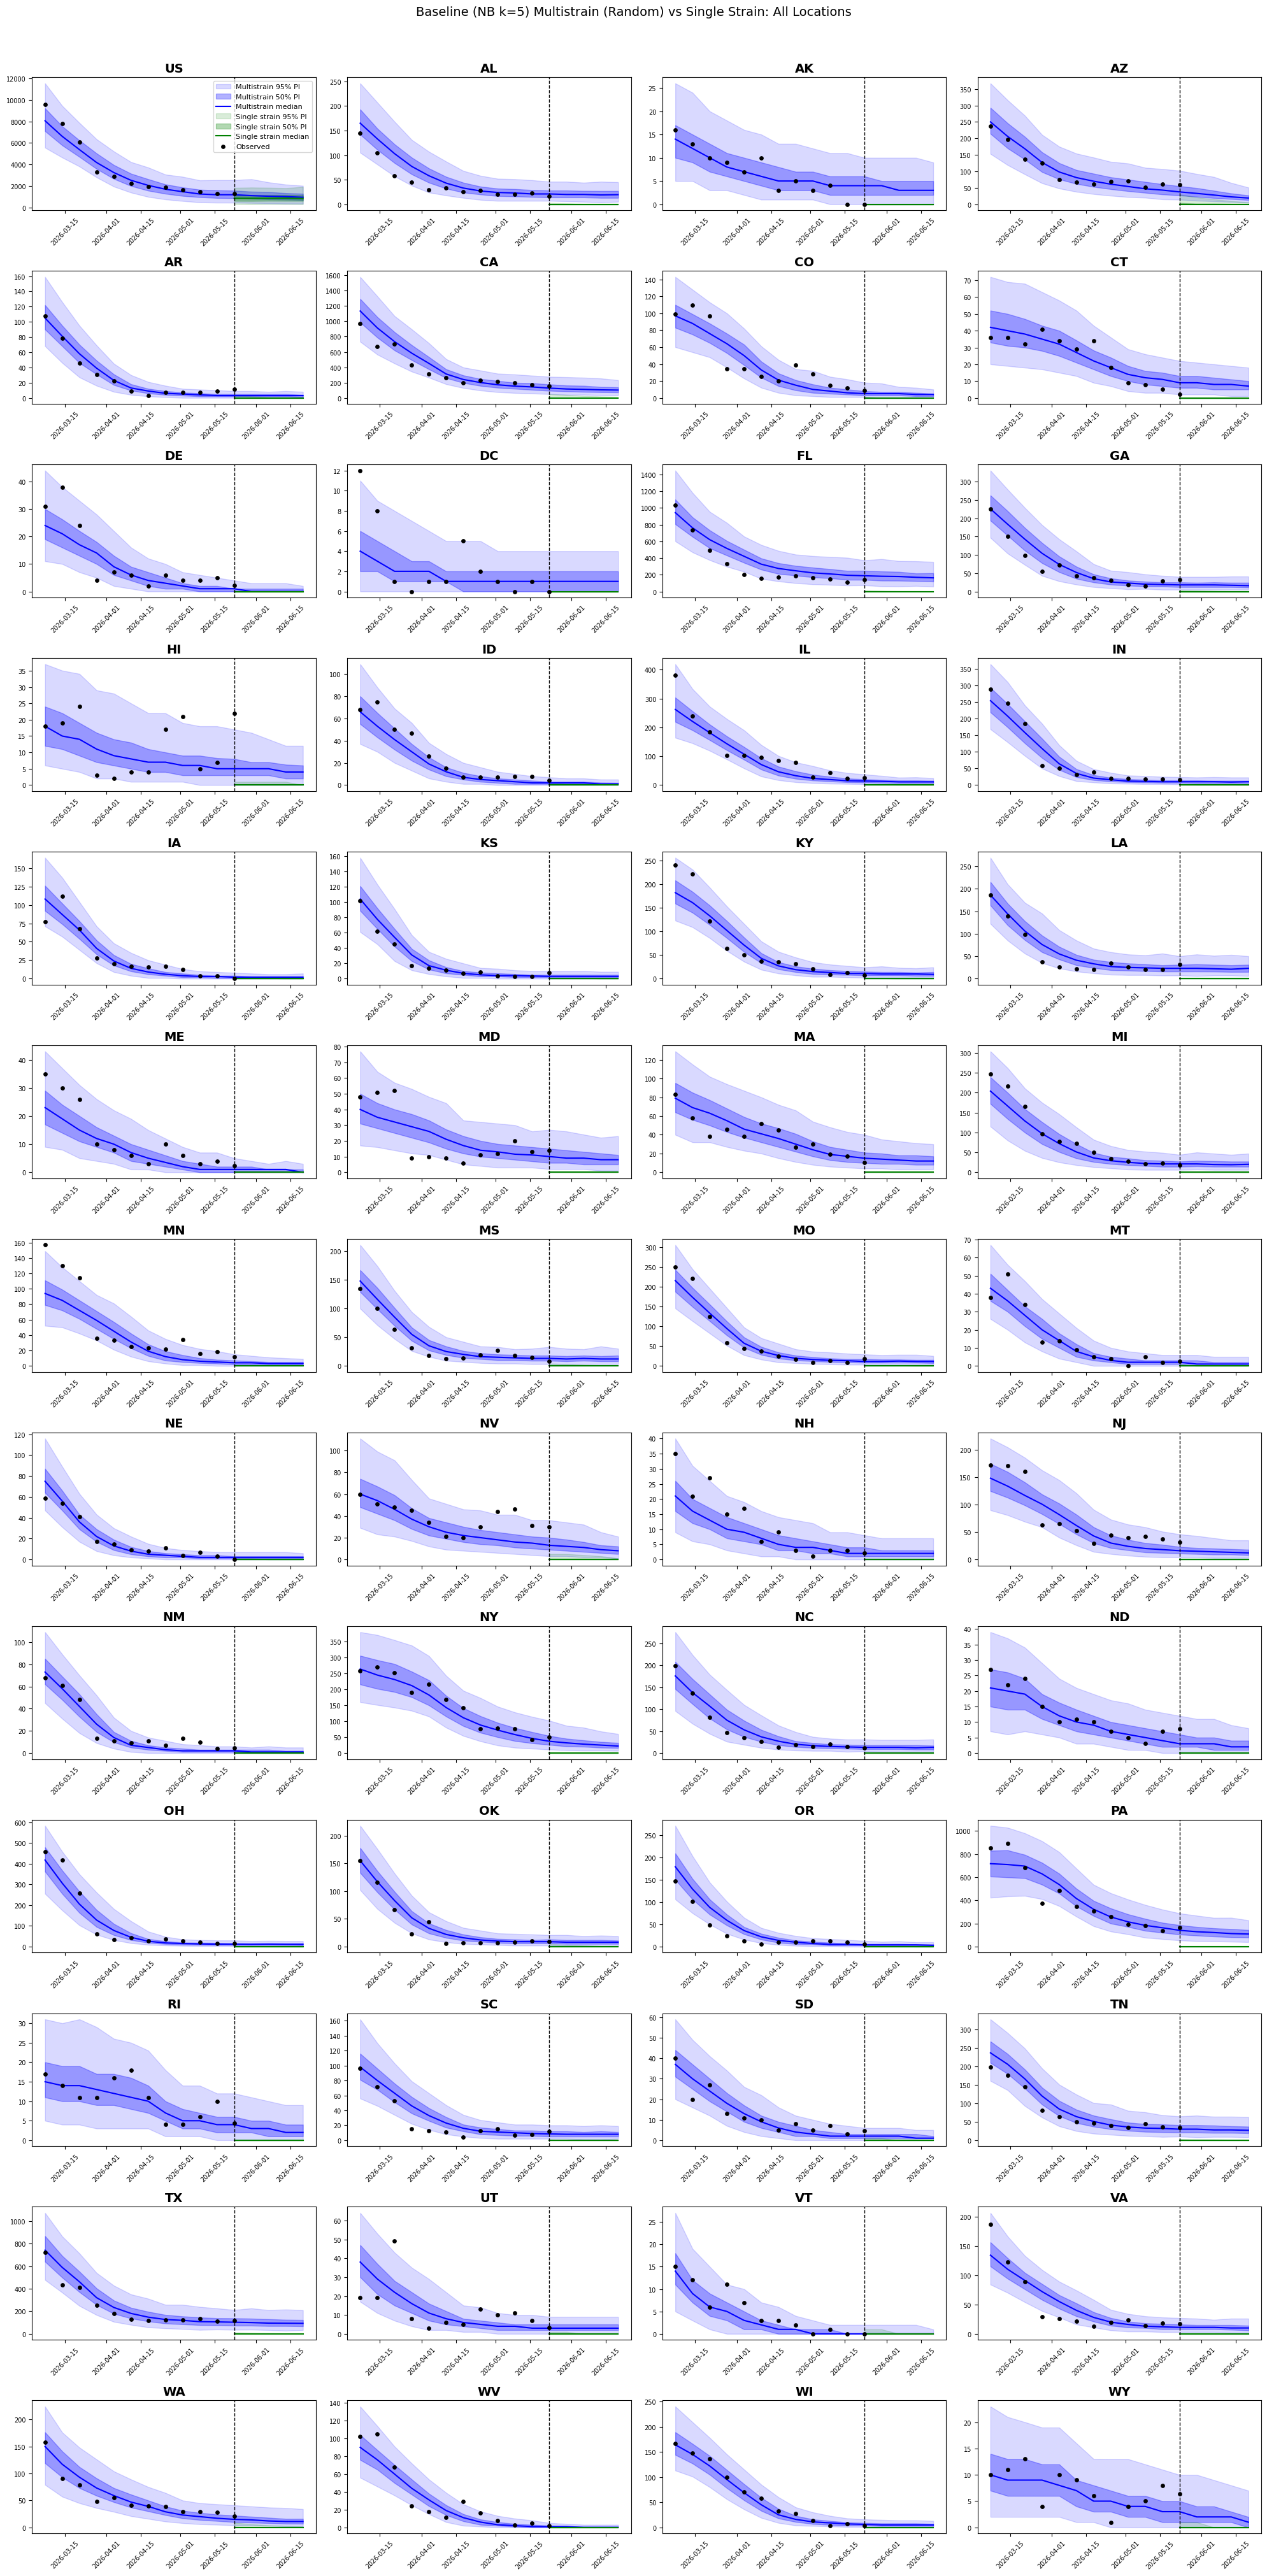

In [9]:
FILTER_PLOT = False
FILTER_PLOT_START = '2026-10-01'
LONG_PLOT_START = '2026-03-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    fname_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    fname_prefix = ''

if BASELINE:
    plot_title = f'Baseline (NB k={BASELINE_k}) Multistrain (Random) vs Single Strain: All Locations'
    fname_prefix += 'baseline_'
else:
    plot_title = 'Multistrain (Random) vs Single Strain: All Locations'

plot_fname = f"{fname_prefix}{SUBMISSION_WEEK}_multistrain_vs_single_comparison.pdf"

# Filter data
random_quantiles_filter = random_quantiles[
    (random_quantiles['date'] >= plot_start_date) &
    (random_quantiles['date'] < final_date)
]
fit_surv_data_filter = fit_surv_data[
    (fit_surv_data['date'] >= plot_start_date) &
    (fit_surv_data['date'] < final_date)
]

if INCLUDE_SINGLE_STRAIN:
    # Convert df_single to wide format for plotting (matching random_quantiles format)
    df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
    df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])
    
    # Pivot to get quantile columns
    df_single_wide = df_single_quantiles.pivot_table(
        index=['location', 'target_end_date'],
        columns='output_type_id',
        values='value'
    ).reset_index()
    
    # Rename columns to match random_quantiles format
    df_single_wide.columns.name = None
    df_single_wide = df_single_wide.rename(columns={
        'target_end_date': 'date',
        '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
    })
    
    # Filter to date range
    df_single_filter = df_single_wide[
        (df_single_wide['date'] >= plot_start_date) & 
        (df_single_wide['date'] < final_date)
    ]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = convert_location_name_format(
        value=pop,
        output_format="abbreviation",
        location_type="iso"
    )
    location_code = convert_location_name_format(
        value=abbrev,
        output_format="FIPS",
        input_format="abbreviation",
        location_type="iso"
    )
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    hosp_pop = fit_surv_data_filter[fit_surv_data_filter['abbreviation'] == abbrev].sort_values('date')
    if INCLUDE_SINGLE_STRAIN:
        single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    if INCLUDE_SINGLE_STRAIN:
        ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                        alpha=0.15, color='green', label='Single strain 95% PI')
        ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                        alpha=0.3, color='green', label='Single strain 50% PI')
        ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(hosp_pop['date'], hosp_pop['hospitalizations'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)
    
plt.suptitle(plot_title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{LOCAL_PARENT_DIR}/plots/{plot_fname}', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [10]:
# Compute rate trend categories for each trajectory
# Baseline comes from surveillance data, target from trajectories
categories_df = compute_rate_trend_categories(
    df=random_combined,
    reference_date=REFERENCE_DATE,
    surveillance_df=fit_surv_data,
    horizons=get_flusight_categorical_horizons(),
    value_col=VALUE_COL,
    surveillance_date_col='date',
    surveillance_value_col='hospitalizations',
    surveillance_location_col='abbreviation'
)

print(f"Categories computed: {len(categories_df):,} rows")
print(f"Unique populations: {categories_df['population'].nunique()}")
print(f"Horizons: {sorted(categories_df['horizon'].unique())}")
print(f"\nCategory distribution:")
print(categories_df['category'].value_counts())
print(f"\nBaseline values come from surveillance (same for all samples per location):")
categories_df.tail(10)

Categories computed: 208,000 rows
Unique populations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Category distribution:
category
stable            197658
decrease            8071
increase            2263
large_increase         8
Name: count, dtype: int64

Baseline values come from surveillance (same for all samples per location):


,reference_date,sample_id,population,abbreviation,baseline_date,horizon,target_date,baseline_value,target_value,count_change,rate_change,category
207990,2026-05-30,240,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,4.0,-2.447576,-0.416525,stable
207991,2026-05-30,221,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,2.0,-4.447576,-0.756882,stable
207992,2026-05-30,961,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207993,2026-05-30,339,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207994,2026-05-30,419,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,1.0,-5.447576,-0.927061,stable
207995,2026-05-30,847,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,2.0,-4.447576,-0.756882,stable
207996,2026-05-30,179,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207997,2026-05-30,465,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207998,2026-05-30,516,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable
207999,2026-05-30,529,United_States__Wyoming,WY,2026-05-23,3,2026-06-20,6.447576,0.0,-6.447576,-1.097239,stable


In [11]:
# Compute PMF from categories
pmf_df = compute_rate_trend_pmf(categories_df)

print(f"PMF shape: {pmf_df.shape}")
print(f"Columns: {pmf_df.columns.tolist()}")
print(f"\nProbabilities sum to 1: {(pmf_df[RATE_TREND_CATEGORIES].sum(axis=1).round(6) == 1).all()}")

PMF shape: (208, 9)
Columns: ['population', 'abbreviation', 'horizon', 'target_date', 'large_decrease', 'decrease', 'stable', 'increase', 'large_increase']

Probabilities sum to 1: True


In [12]:
# Format PMF for hub submission (long format)
pmf_long = pmf_df.melt(
    id_vars=['population', 'abbreviation', 'horizon', 'target_date'],
    value_vars=RATE_TREND_CATEGORIES,
    var_name='output_type_id',
    value_name='value'
)

# Add required columns for FluSight format
pmf_long['target'] = 'wk flu hosp rate change'
pmf_long['output_type'] = 'pmf'
pmf_long['location'] = pmf_long['abbreviation']

# Reorder columns
hub_pmf = pmf_long[[
    'location', 'target', 'horizon', 'target_date', 
    'output_type', 'output_type_id', 'value'
]]

print(f"Hub submission format shape: {hub_pmf.shape}")
print(f"\nSample rows:")
hub_pmf.head(15)

Hub submission format shape: (1040, 7)

Sample rows:


,location,target,horizon,target_date,output_type,output_type_id,value
0,US,wk flu hosp rate change,0,2026-05-30,pmf,large_decrease,0.0
1,US,wk flu hosp rate change,1,2026-06-06,pmf,large_decrease,0.0
2,US,wk flu hosp rate change,2,2026-06-13,pmf,large_decrease,0.0
3,US,wk flu hosp rate change,3,2026-06-20,pmf,large_decrease,0.0
4,AL,wk flu hosp rate change,0,2026-05-30,pmf,large_decrease,0.0
5,AL,wk flu hosp rate change,1,2026-06-06,pmf,large_decrease,0.0
6,AL,wk flu hosp rate change,2,2026-06-13,pmf,large_decrease,0.0
7,AL,wk flu hosp rate change,3,2026-06-20,pmf,large_decrease,0.0
8,AK,wk flu hosp rate change,0,2026-05-30,pmf,large_decrease,0.0
9,AK,wk flu hosp rate change,1,2026-06-06,pmf,large_decrease,0.0


In [13]:
# Export PMF for hub submission (uncomment to save)
# output_file = f"../data/multistrain-data/{SUBMISSION_WEEK}/rate_trend_pmf.csv"
# hub_pmf.to_csv(output_file, index=False)
# print(f"Saved PMF to: {output_file}")

# Verify probabilities sum to 1 for each location/horizon
verification = hub_pmf.groupby(['location', 'horizon'])['value'].sum()
print("All PMFs sum to 1:", (verification.round(6) == 1).all())
print(f"\nTotal PMF entries: {len(hub_pmf)}")
print(f"Locations: {hub_pmf['location'].nunique()}")
print(f"Horizons: {sorted(hub_pmf['horizon'].unique())}")
print(f"Categories per location/horizon: {len(RATE_TREND_CATEGORIES)}")

All PMFs sum to 1: True

Total PMF entries: 1040
Locations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Categories per location/horizon: 5


In [14]:
# Create complete FluSight submission
submission = create_flusight_submission(
    trajectories_df=random_combined,
    pmf_df=pmf_df,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),
    value_col=VALUE_COL
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (7020, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk flu hosp rate change', 'wk inc flu hosp']
Length: 2, dtype: str
Output types: <StringArray>
['pmf', 'quantile']
Length: 2, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 52

Rows per target:
target                   output_type
wk flu hosp rate change  pmf            1040
wk inc flu hosp          quantile       5980
dtype: int64


In [15]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,decrease,0.000
1,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,increase,0.164
2,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,large_decrease,0.000
3,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,large_increase,0.000
4,2026-05-30,0,2026-05-30,01,wk flu hosp rate change,pmf,stable,0.836
...,...,...,...,...,...,...,...,...
7015,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.85,1449.000
7016,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.9,1584.000
7017,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.95,1787.000
7018,2026-05-30,3,2026-06-20,US,wk inc flu hosp,quantile,0.975,2014.000


In [16]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"{LOCAL_PARENT_DIR}/submissions/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)